In [ ]:
print("Hello! My AI project has started.")

Hello! My AI project has started.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 1, 4, 6, 8, 5, 7, 3],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95, 55, 72, 82, 92, 78, 88, 63],
    "Previous_Score": [45, 50, 55, 60, 65, 70, 75, 85, 40, 58, 68, 80, 62, 73, 48],
    "Final_Score": [48, 52, 58, 63, 68, 73, 78, 88, 42, 61, 71, 83, 66, 76, 51]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
df

Dataset created successfully!


,Study_Hours,Attendance,Previous_Score,Final_Score
0,2,60,45,48
1,3,65,50,52
2,4,70,55,58
3,5,75,60,63
4,6,80,65,68
5,7,85,70,73
6,8,90,75,78
7,9,95,85,88
8,1,55,40,42
9,4,72,58,61


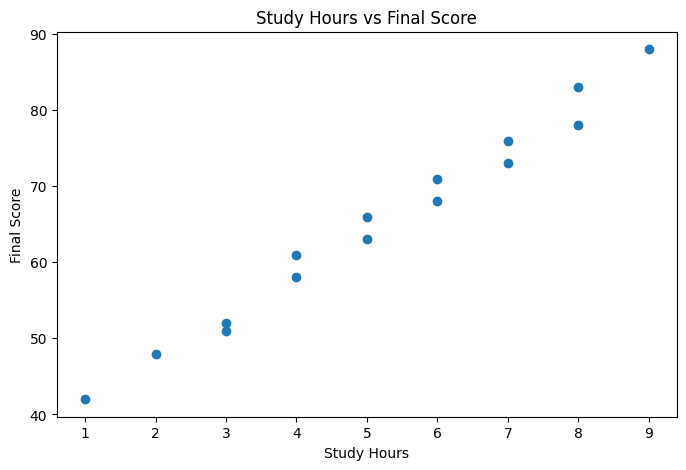

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Final_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

In [ ]:
X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 12
Testing data: 3


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual Scores:")
print(y_test.values)

print("\nPredicted Scores:")
print(y_pred.round(2))

Actual Scores:
[61 83 48]

Predicted Scores:
[60.79 83.09 47.48]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 0.27
R² Score: 1.0


In [ ]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Score": [70]
})

predicted_score = model.predict(new_student)

print("Predicted Final Score:", round(predicted_score[0], 2))

Predicted Final Score: 73.4


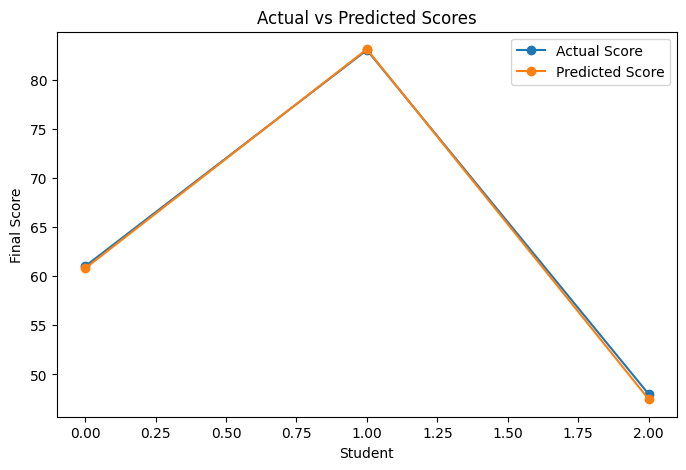

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, marker='o', label='Actual Score')
plt.plot(y_pred, marker='o', label='Predicted Score')

plt.xlabel("Student")
plt.ylabel("Final Score")
plt.title("Actual vs Predicted Scores")
plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("Mean Absolute Error:", round(rf_mae, 2))
print("R² Score:", round(rf_r2, 2))

Random Forest Results
Mean Absolute Error: 2.07
R² Score: 0.97


Feature Importance:
Attendance        0.366837
Study_Hours       0.322730
Previous_Score    0.310433
dtype: float64


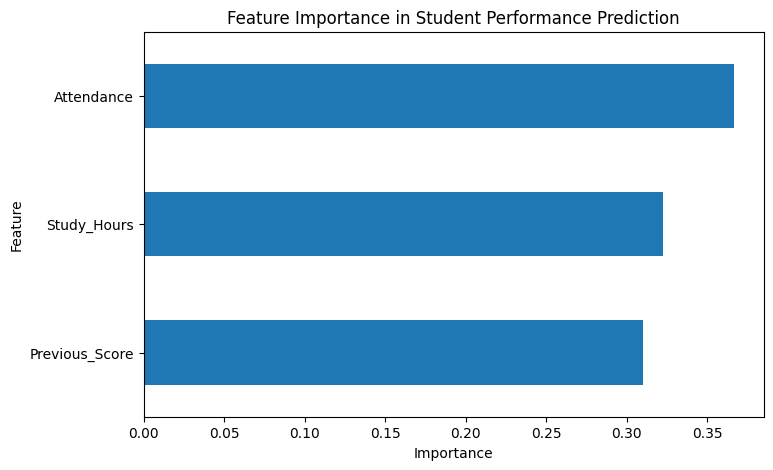

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

print("Feature Importance:")
print(feature_importance.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Student Performance Prediction")

plt.show()